In [2]:
import os
import pyvista as pv
import imageio.v2 as imageio  # v2 interface for backward compatibility
from natsort import natsorted  # for natural sorting of filenames

from IPython.display import Image, display

In [3]:
def generate_vti_animation(directory, output_gif='animation.gif', field_name=None, fps=5):
    """
    Generates a GIF animation from a directory of .vti files.

    Args:
        directory (str): Path to the directory containing .vti files.
        output_gif (str): Filename for the output GIF.
        field_name (str, optional): Specific scalar field to plot (defaults to the first scalar if None).
        fps (int): Frames per second for the animation.
    """
    # List .vti files in natural order
    vti_files = natsorted([f for f in os.listdir(directory) if f.endswith('.vti')])
    if not vti_files:
        raise FileNotFoundError("No VTI files found in the directory.")

    # Prepare PyVista plotter
    plotter = pv.Plotter(off_screen=True)
    frames = []

    for fname in vti_files:
        filepath = os.path.join(directory, fname)
        grid = pv.read(filepath)

        # Pick default field if not provided
        if field_name is None:
            field_name = list(grid.point_data.keys())[0]

        plotter.clear()
        plotter.add_mesh(grid, scalars=field_name, cmap='viridis')
        plotter.camera_position = 'xy'
        img = plotter.screenshot()
        frames.append(img)

    # Save GIF
    imageio.mimsave(output_gif, frames, fps=fps)
    print(f"Animation saved to: {output_gif}")


Animation saved to: wave.gif


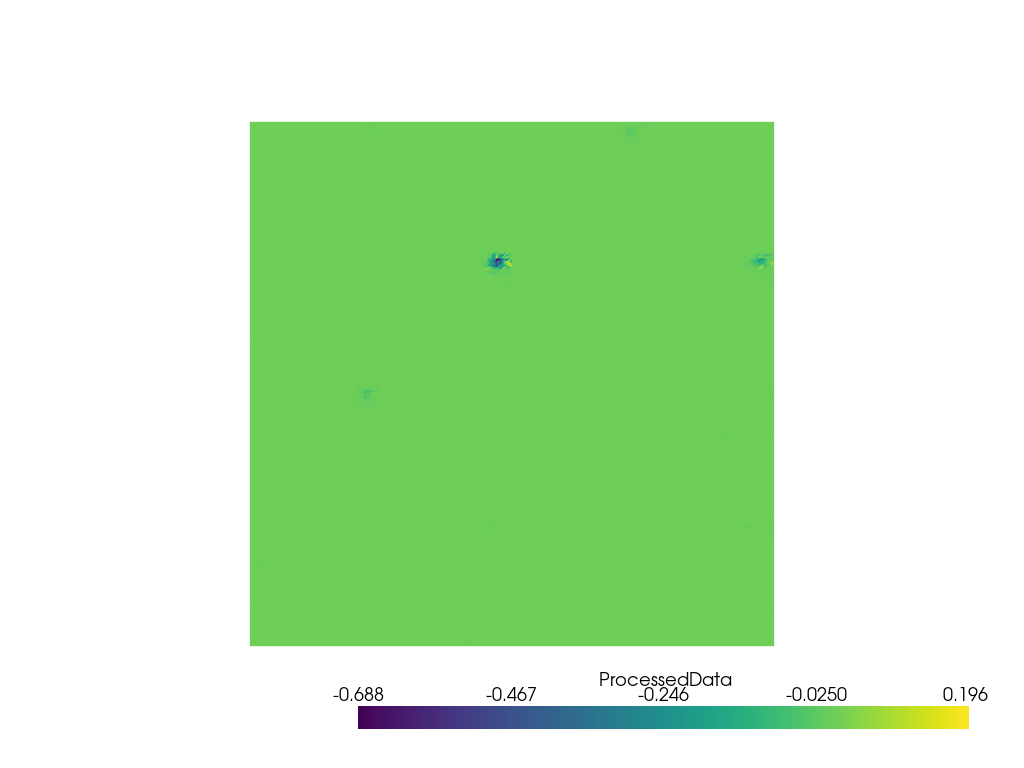

In [4]:
generate_vti_animation('./results/constant_vel', output_gif='wave.gif')
display(Image(filename='wave.gif'))

Animation saved to: pp_wave.gif


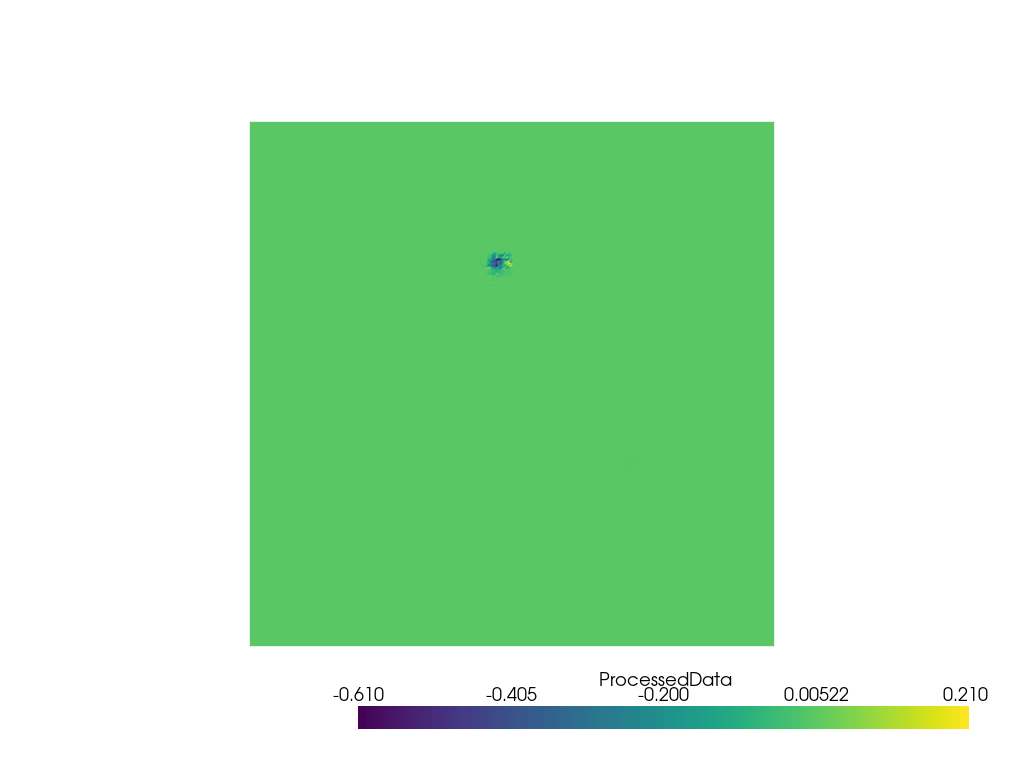

In [5]:
generate_vti_animation('./results/parallel_planes', output_gif='pp_wave.gif')
display(Image(filename='pp_wave.gif'))